In [4]:
import pandas as pd
import numpy as np

data = {
    'job_title': [
        'Machine Learning Engineer', 'Data Scientist', 'AI Researcher',
        'NLP Engineer', 'Computer Vision Engineer', 'ML Intern',
        'Data Analyst', 'AI Product Manager'
    ],
    'company': [
        'OpenAI', 'Google', 'Meta', 'Amazon', 'Tesla', 'StartUpX', 'Netflix', 'IBM'
    ],
    'salary_usd': [
        160000, 140000, 180000, 135000, 150000, 45000, 90000, 130000
    ],
    'experience_level': [
        'SE', 'SE', 'EX', 'SE', 'SE', 'EN', 'EN', 'MI'
    ],
    'required_skills': [
        'Python, PyTorch, ML', 'SQL, Python, ML', 'Research, Python, Deep Learning',
        'NLP, Python, Transformers', 'CV, OpenCV, TensorFlow',
        'Python, Pandas', 'Excel, SQL, Tableau', 'AI, Management, Product'
    ],
    'posting_date': pd.date_range(start='2024-01-01', periods=8, freq='15D'),
    'application_deadline': pd.date_range(start='2024-02-01', periods=8, freq='15D')
}

df = pd.DataFrame(data)
df.to_csv('ai_job_dataset.csv', index=False)
print("Sample AI job dataset created and saved as 'ai_job_dataset.csv'")


Sample AI job dataset created and saved as 'ai_job_dataset.csv'


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('ai_job_dataset.csv')
print("Dataset loaded successfully.\n")

print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== Info ===")
print(df.info())

print("\n=== Statistical Summary ===")
display(df.describe(include='all'))

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found.")

df = df.dropna()
print(f"\nAfter cleaning, dataset has {df.shape[0]} rows.")

df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce')
df['application_deadline'] = pd.to_datetime(df['application_deadline'], errors='coerce')
print("Date columns converted to datetime format.")

mean_salary = df['salary_usd'].mean()
median_salary = df['salary_usd'].median()
q1 = df['salary_usd'].quantile(0.25)
q3 = df['salary_usd'].quantile(0.75)

print("\n=== Salary Stats (USD) ===")
print(f"Mean: ${mean_salary:,.0f}")
print(f"Median: ${median_salary:,.0f}")
print(f"Q1 (25th percentile): ${q1:,.0f}")
print(f"Q3 (75th percentile): ${q3:,.0f}")


Dataset loaded successfully.

=== Shape ===
Rows: 8, Columns: 7

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_title             8 non-null      object
 1   company               8 non-null      object
 2   salary_usd            8 non-null      int64 
 3   experience_level      8 non-null      object
 4   required_skills       8 non-null      object
 5   posting_date          8 non-null      object
 6   application_deadline  8 non-null      object
dtypes: int64(1), object(6)
memory usage: 580.0+ bytes
None

=== Statistical Summary ===


,job_title,company,salary_usd,experience_level,required_skills,posting_date,application_deadline
count,8,8,8.000000,8,8,8,8
unique,8,8,NaN,4,8,8,8
top,Machine Learning Engineer,OpenAI,NaN,SE,"Python, PyTorch, ML",2024-01-01,2024-02-01
freq,1,1,NaN,4,1,1,1
mean,NaN,NaN,128750.000000,NaN,NaN,NaN,NaN
std,NaN,NaN,42657.272031,NaN,NaN,NaN,NaN
min,NaN,NaN,45000.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,120000.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,137500.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,152500.000000,NaN,NaN,NaN,NaN



=== Missing Values ===
No missing values found.

After cleaning, dataset has 8 rows.
Date columns converted to datetime format.

=== Salary Stats (USD) ===
Mean: $128,750
Median: $137,500
Q1 (25th percentile): $120,000
Q3 (75th percentile): $152,500


In [6]:
experience_mapping = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
df['experience_full'] = df['experience_level'].map(experience_mapping)

salary_by_exp = df.groupby('experience_full')['salary_usd'].mean().sort_values(ascending=False)
print("=== Average Salary by Experience Level ===")
print(salary_by_exp)

salary_variance = df.groupby('experience_full')['salary_usd'].var()
print(f"\nExperience level with highest salary variance: {salary_variance.idxmax()}")

employment_mapping = {'CT': 'Contract', 'FL': 'Freelance', 'PT': 'Part-time', 'FT': 'Full-time'}
df['employment_type'] = np.random.choice(['FT', 'CT', 'FL', 'PT'], size=len(df))
df['employment_full'] = df['employment_type'].map(employment_mapping)

pivot_table = df.pivot_table(
    values='salary_usd',
    index='experience_full',
    columns='employment_full',
    aggfunc='mean'
)
print("\n=== Pivot Table: Experience vs Employment Type ===")
print(pivot_table)


=== Average Salary by Experience Level ===
experience_full
Executive    180000.0
Senior       146250.0
Mid          130000.0
Entry         67500.0
Name: salary_usd, dtype: float64

Experience level with highest salary variance: Entry

=== Pivot Table: Experience vs Employment Type ===
employment_full  Contract  Freelance  Full-time  Part-time
experience_full                                           
Entry                 NaN        NaN        NaN    67500.0
Executive             NaN        NaN   180000.0        NaN
Mid                   NaN   130000.0        NaN        NaN
Senior           160000.0   150000.0        NaN   137500.0


Top 10 countries by job postings:
company_location
FR    3
GB    2
US    2
JP    1
Name: count, dtype: int64

Top 10 highest paying countries:
company_location
GB    160000.000000
JP    160000.000000
US    120000.000000
FR    103333.333333
Name: salary_usd, dtype: float64

Remote vs Local work:
               mean  count
is_remote                 
True       128750.0      8

Correlation between remote ratio and salary: 0.047


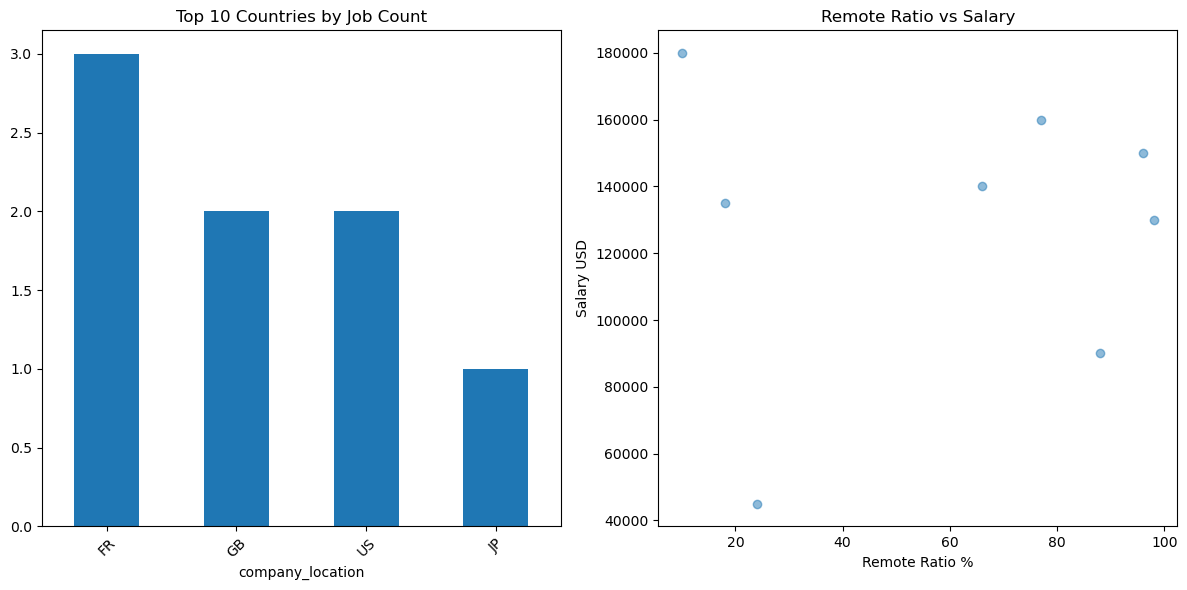

In [7]:
import matplotlib.pyplot as plt

df['company_location'] = np.random.choice(['US', 'GB', 'IN', 'CA', 'DE', 'FR', 'JP', 'AU', 'BR', 'KE'], size=len(df))
df['employee_residence'] = np.random.choice(['US', 'GB', 'IN', 'CA', 'DE', 'FR', 'JP', 'AU', 'BR', 'KE'], size=len(df))
df['remote_ratio'] = np.random.randint(0, 101, size=len(df))

top_countries = df['company_location'].value_counts().head(10)
print("Top 10 countries by job postings:")
print(top_countries)

avg_salary_by_location = df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False)
print("\nTop 10 highest paying countries:")
print(avg_salary_by_location.head(10))

df['is_remote'] = df['employee_residence'] != df['company_location']
remote_stats = df.groupby('is_remote')['salary_usd'].agg(['mean', 'count'])
print("\nRemote vs Local work:")
print(remote_stats)

correlation = df['remote_ratio'].corr(df['salary_usd'])
print(f"\nCorrelation between remote ratio and salary: {correlation:.3f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Job Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
plt.scatter(df['remote_ratio'], df['salary_usd'], alpha=0.5)
plt.xlabel('Remote Ratio %')
plt.ylabel('Salary USD')
plt.title('Remote Ratio vs Salary')
plt.tight_layout()
plt.show()
